# Machine Learning Phase

In this section, I apply machine learning methods to analyze AI-related job market data. The main goal is to predict job experience level and salary using features such as demand score, education requirement, required skills, and AI salary premium.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import warnings
warnings.filterwarnings("ignore")

## Loading the Dataset

Now I load the cleaned dataset created in the previous phase of the project.

In [2]:
df = pd.read_csv("ai_jobs_market_cleaned.xls")
df.head()

,job_category,experience_level,years_of_experience,education_required,annual_salary_usd,salary_min_usd,salary_max_usd,industry,required_skills,ai_salary_premium_pct,demand_score,demand_growth_yoy_pct,benefits_score_10,is_llm_role,entry_vs_senior,salary_midpoint_check
0,AI Engineering,Senior,7,Master,239000.0,155000,290000,Finance,APIs|Planning Systems|Python|Cloud|SQL|Leadership,13.1,96,16.9,6.8,1,Senior,222500.0
1,AI Engineering,Senior,2,Bachelor,166000.0,90000,200000,Finance,Python|Documentation|LLM APIs|Prompt Design|NL...,5.4,82,11.6,6.2,1,Senior,145000.0
2,AI Engineering,Senior,4,Associate,360000.0,160000,300000,Finance,Vector DBs|Python|Prompt Engineering|Fine-tuni...,9.1,98,42.7,7.7,1,Senior,230000.0
3,Data Engineering,Senior,3,Bachelor,161000.0,130000,220000,Technology,Feature Stores|Spark|ETL|Airflow|dbt|SQL|Pytho...,12.0,88,6.7,9.5,0,Senior,175000.0
4,Product,Lead,5,Bootcamp/Self-taught,283000.0,140000,260000,Automotive,Data Analysis|Stakeholder Mgmt|Agile|Cloud|Pro...,9.4,85,17.3,8.9,0,Other,200000.0


## Selecting Features for Machine Learning

To keep the model focused and interpretable, I select variables related to salary, demand, education, skills, and experience level.

In [3]:
selected_columns = [
    "demand_score",
    "annual_salary_usd",
    "ai_salary_premium_pct",
    "education_required",
    "required_skills",
    "experience_level"
]

df_ml = df[selected_columns].copy()
df_ml.head()

,demand_score,annual_salary_usd,ai_salary_premium_pct,education_required,required_skills,experience_level
0,96,239000.0,13.1,Master,APIs|Planning Systems|Python|Cloud|SQL|Leadership,Senior
1,82,166000.0,5.4,Bachelor,Python|Documentation|LLM APIs|Prompt Design|NL...,Senior
2,98,360000.0,9.1,Associate,Vector DBs|Python|Prompt Engineering|Fine-tuni...,Senior
3,88,161000.0,12.0,Bachelor,Feature Stores|Spark|ETL|Airflow|dbt|SQL|Pytho...,Senior
4,85,283000.0,9.4,Bootcamp/Self-taught,Data Analysis|Stakeholder Mgmt|Agile|Cloud|Pro...,Lead


## Defining the First ML Task

The first task is a classification problem.  
I will try to predict the **experience level** of a job posting using the other features.

In [4]:
X = df_ml.drop("experience_level", axis=1)
y = df_ml["experience_level"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nClasses:")
print(y.value_counts())

Features shape: (1500, 5)
Target shape: (1500,)

Classes:
experience_level
Entry     385
Lead      381
Mid       370
Senior    364
Name: count, dtype: int64


## Splitting the Data

I divide the dataset three two parts:

- **60% Training Set:** used to train the model and learn patterns from the data
- **20% Validation Set:** used to compare the performances
- **20% Test Set:** used to evaluate model performance on unseen data


In [5]:
# Prepare classification features and target

X = df_ml.drop("experience_level", axis=1)
y = df_ml["experience_level"]

# Split the classification data into training, validation, and test sets

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval,
    y_trainval,
    test_size=0.25,
    random_state=42,
    stratify=y_trainval
)

print("Training set size:", X_train.shape[0])
print("Validation set size:", X_val.shape[0])
print("Test set size:", X_test.shape[0])

Training set size: 900
Validation set size: 300
Test set size: 300


## Training the First Classification Model

I start with **Logistic Regression** as a baseline classification model.  


In [6]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_transformer, numeric_features),
        ("categoric", categorical_transformer, categorical_features)
    ]
)

log_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

log_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Numeric features: ['demand_score', 'annual_salary_usd', 'ai_salary_premium_pct']
Categorical features: ['education_required', 'required_skills']
Logistic Regression model trained successfully.


The figure below presents the machine learning pipeline. Numerical features were cleaned and scaled, categorical features were encoded, and the processed data was then used to train the Logistic Regression model.

## Making Predictions

After training the model, I use the test dataset to predict experience levels for unseen job postings.

In [7]:
y_pred = log_model.predict(X_test)

## Evaluating Model Performance

To evaluate the model, I use accuracy score and classification metrics such as precision, recall, and F1-score.

In [8]:
print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy Score: 0.44666666666666666

Classification Report:

              precision    recall  f1-score   support

       Entry       0.48      0.82      0.60        77
        Lead       0.49      0.58      0.53        76
         Mid       0.39      0.22      0.28        74
      Senior       0.30      0.15      0.20        73

    accuracy                           0.45       300
   macro avg       0.41      0.44      0.40       300
weighted avg       0.41      0.45      0.41       300



## Confusion Matrix

To better understand the model's predictions, I use a confusion matrix. It shows how many job postings were correctly classified and where the model confused different experience levels.

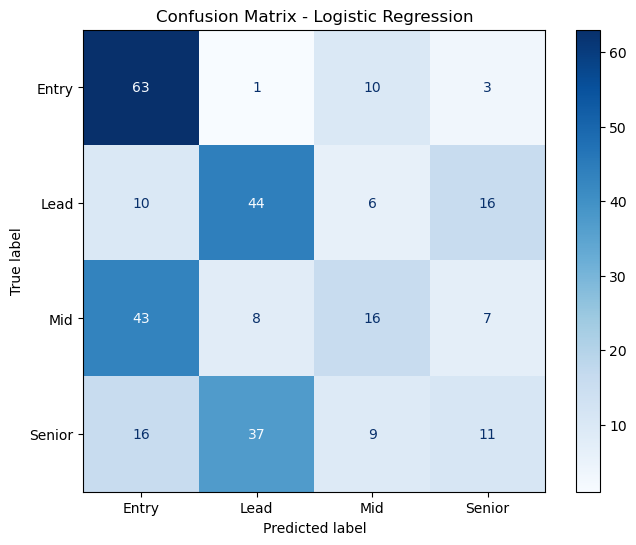

In [9]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

labels = ["Entry", "Lead", "Mid", "Senior"]

cm = confusion_matrix(y_test, y_pred, labels=labels)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)

fig, ax = plt.subplots(figsize=(8,6))
disp.plot(cmap="Blues", ax=ax, values_format="d")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

The confusion matrix shows that the model predicts Entry and Lead positions more accurately, while Mid and Senior roles are more frequently misclassified.

## Improving the Model with Gradient Boosting

After using Logistic Regression as a baseline model, I apply Gradient Boosting Classifier as a stronger method. This model builds multiple weak learners step by step and often performs better on structured datasets.

In [10]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    ))
])

gb_model.fit(X_train, y_train)

print("Gradient Boosting Classifier model trained successfully.")

Gradient Boosting Classifier model trained successfully.


## Visualizing Gradient Boosting Predictions

I use a confusion matrix again to see how the Gradient Boosting model predicts each experience level.

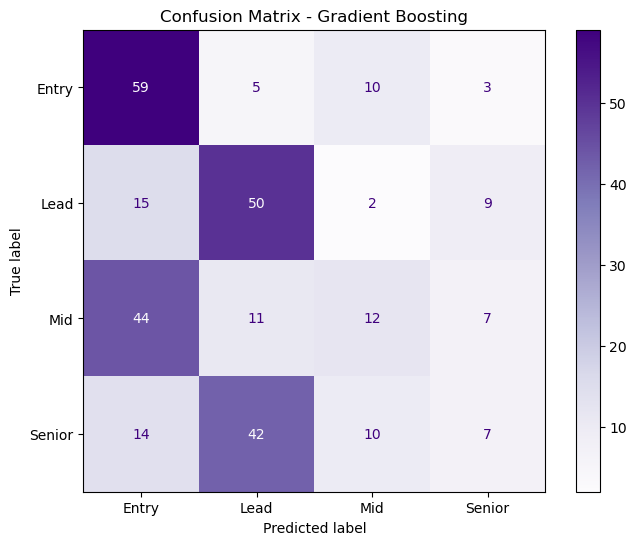

In [11]:
y_pred_gb = gb_model.predict(X_test)

cm_gb = confusion_matrix(y_test, y_pred_gb, labels=labels)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_gb, display_labels=labels)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap="Purples", ax=ax, values_format="d")
plt.title("Confusion Matrix - Gradient Boosting")
plt.show()

Gradient Boosting did not improve the results significantly because the selected features may not contain enough information to clearly separate experience levels. In many cases, Entry, Mid, and Senior roles can have similar salaries, skills, or education requirements, which makes classification difficult even for more advanced models.

In [12]:
# Compare classification models using multiple metrics

models = {
    "Logistic Regression": log_model,
    "Gradient Boosting": gb_model
}

classification_results = []

for model_name, model in models.items():
    # Predictions
    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)
    y_test_pred = model.predict(X_test)
    
    # Store results
    classification_results.append({
        "Model": model_name,
        "Dataset": "Training",
        "Accuracy": accuracy_score(y_train, y_train_pred),
        "Precision": precision_score(y_train, y_train_pred, average="weighted", zero_division=0),
        "Recall": recall_score(y_train, y_train_pred, average="weighted", zero_division=0),
        "F1": f1_score(y_train, y_train_pred, average="weighted", zero_division=0)
    })
    
    classification_results.append({
        "Model": model_name,
        "Dataset": "Validation",
        "Accuracy": accuracy_score(y_val, y_val_pred),
        "Precision": precision_score(y_val, y_val_pred, average="weighted", zero_division=0),
        "Recall": recall_score(y_val, y_val_pred, average="weighted", zero_division=0),
        "F1": f1_score(y_val, y_val_pred, average="weighted", zero_division=0)
    })
    
    classification_results.append({
        "Model": model_name,
        "Dataset": "Test",
        "Accuracy": accuracy_score(y_test, y_test_pred),
        "Precision": precision_score(y_test, y_test_pred, average="weighted", zero_division=0),
        "Recall": recall_score(y_test, y_test_pred, average="weighted", zero_division=0),
        "F1": f1_score(y_test, y_test_pred, average="weighted", zero_division=0)
    })

classification_results_df = pd.DataFrame(classification_results)
classification_results_df

,Model,Dataset,Accuracy,Precision,Recall,F1
0,Logistic Regression,Training,0.914444,0.920026,0.914444,0.915752
1,Logistic Regression,Validation,0.433333,0.400060,0.433333,0.396297
2,Logistic Regression,Test,0.446667,0.414954,0.446667,0.406338
3,Gradient Boosting,Training,0.747778,0.801268,0.747778,0.733542
4,Gradient Boosting,Validation,0.420000,0.400059,0.420000,0.385793
5,Gradient Boosting,Test,0.426667,0.384578,0.426667,0.371819


### Classification Model Comparison

The classification models were compared using accuracy, precision, recall, and F1-score. This is important because accuracy alone may not show whether the model performs well across all experience-level groups. The validation set was used to compare model performance before evaluating the final test results.

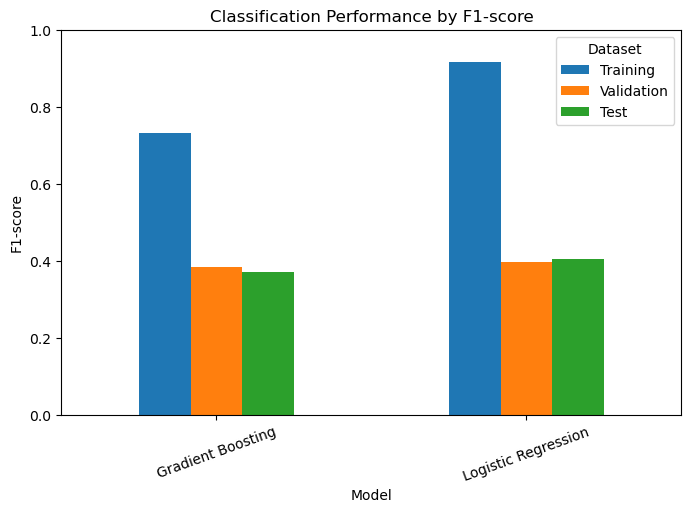

In [13]:
# Visualize classification F1 scores

classification_plot = classification_results_df.pivot(
    index="Model",
    columns="Dataset",
    values="F1"
)

classification_plot = classification_plot[["Training", "Validation", "Test"]]

classification_plot.plot(kind="bar", figsize=(8, 5))
plt.title("Classification Performance by F1-score")
plt.ylabel("F1-score")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.show()

## Hyperparameter Tuning with GridSearchCV

To improve the Gradient Boosting Classifier, I used GridSearchCV to test different hyperparameter combinations. Instead of manually choosing model settings, GridSearchCV compares several options using cross-validation and selects the best-performing combination.

For this classification task, I used F1-score as the main tuning metric because it gives a more balanced evaluation than accuracy alone.

In [14]:
# Hyperparameter tuning for Gradient Boosting Classifier using GridSearchCV

param_grid = {
    "classifier__n_estimators": [50, 100],
    "classifier__learning_rate": [0.05, 0.1],
    "classifier__max_depth": [2, 3]
}

grid_search = GridSearchCV(
    estimator=gb_model,
    param_grid=param_grid,
    cv=3,
    scoring="f1_weighted"
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best cross-validation F1 score:", grid_search.best_score_)

Best parameters: {'classifier__learning_rate': 0.05, 'classifier__max_depth': 3, 'classifier__n_estimators': 100}
Best cross-validation F1 score: 0.39126576574970245


### GridSearchCV Classification Result

GridSearchCV selected the best Gradient Boosting Classifier with a learning rate of **0.05**, maximum depth of **3**, and **100 estimators**. These values mean that the model performed best when it used 100 boosting steps, learned gradually with a smaller learning rate, and allowed trees with a moderate depth.

The best cross-validation F1-score was approximately **0.391**. This shows that the model has some ability to predict experience levels, but the performance is not very high. This may be because experience levels are difficult to separate using only the available job market features. Some entry-level, mid-level, and senior jobs may share similar salary, demand, skill, and education patterns.

Therefore, hyperparameter tuning improved the model selection process, but it also shows that the classification task itself is challenging.

,Dataset,Accuracy,Precision,Recall,F1
0,Training,0.547778,0.556944,0.547778,0.509440
1,Validation,0.426667,0.406177,0.426667,0.391850
2,Test,0.423333,0.387758,0.423333,0.375655


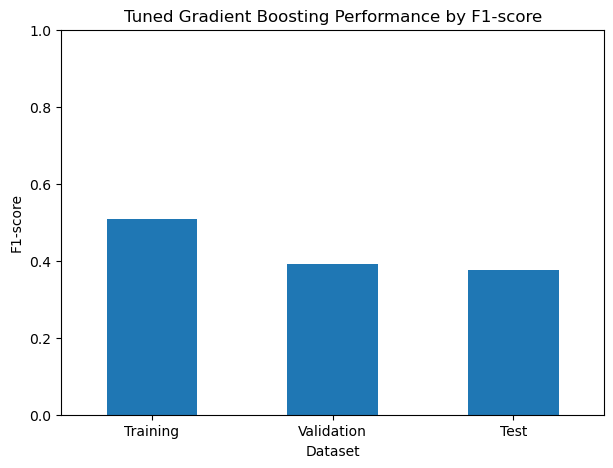

In [15]:
# Evaluate and visualize tuned model performance

best_gb_model = grid_search.best_estimator_

y_train_pred_tuned = best_gb_model.predict(X_train)
y_val_pred_tuned = best_gb_model.predict(X_val)
y_test_pred_tuned = best_gb_model.predict(X_test)

tuned_results = pd.DataFrame([
    {
        "Dataset": "Training",
        "Accuracy": accuracy_score(y_train, y_train_pred_tuned),
        "Precision": precision_score(y_train, y_train_pred_tuned, average="weighted", zero_division=0),
        "Recall": recall_score(y_train, y_train_pred_tuned, average="weighted", zero_division=0),
        "F1": f1_score(y_train, y_train_pred_tuned, average="weighted", zero_division=0)
    },
    {
        "Dataset": "Validation",
        "Accuracy": accuracy_score(y_val, y_val_pred_tuned),
        "Precision": precision_score(y_val, y_val_pred_tuned, average="weighted", zero_division=0),
        "Recall": recall_score(y_val, y_val_pred_tuned, average="weighted", zero_division=0),
        "F1": f1_score(y_val, y_val_pred_tuned, average="weighted", zero_division=0)
    },
    {
        "Dataset": "Test",
        "Accuracy": accuracy_score(y_test, y_test_pred_tuned),
        "Precision": precision_score(y_test, y_test_pred_tuned, average="weighted", zero_division=0),
        "Recall": recall_score(y_test, y_test_pred_tuned, average="weighted", zero_division=0),
        "F1": f1_score(y_test, y_test_pred_tuned, average="weighted", zero_division=0)
    }
])

display(tuned_results)

tuned_results.plot(
    x="Dataset",
    y="F1",
    kind="bar",
    legend=False,
    figsize=(7, 5)
)

plt.title("Tuned Gradient Boosting Performance by F1-score")
plt.ylabel("F1-score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.show()

### Tuned Classification Model Performance

The tuned Gradient Boosting Classifier achieved an accuracy of about **0.548** on the training set, **0.427** on the validation set, and **0.423** on the test set. The F1-score also decreased from **0.509** on the training set to **0.392** on the validation set and **0.376** on the test set.

This shows that the model performs better on the training data than on unseen data. Therefore, there may be some overfitting. However, the validation and test scores are close to each other, which means the model’s performance is consistent on unseen data.

Overall, the classification task is difficult. The model can identify some patterns, but it does not predict experience level very strongly. This may be because experience levels are influenced by many factors that are not fully captured in the dataset, such as job responsibilities, company expectations, and the complexity of required skills.

## Salary Prediction with Regression

After the classification task, I now focus on predicting annual salary. This is a regression problem because salary is a continuous numerical variable.

In [16]:
X_reg = df_ml.drop("annual_salary_usd", axis=1)
y_reg = df_ml["annual_salary_usd"]

## Splitting the Regression Dataset

I divide the data into training and test sets using 60% for training, %20 for validation and 20% for testing.

In [17]:
# Prepare regression features and target

X_reg = df_ml.drop("annual_salary_usd", axis=1)
y_reg = df_ml["annual_salary_usd"]

# Split regression data into training, validation, and test sets

X_trainval_reg, X_test_reg, y_trainval_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.20,
    random_state=42
)

X_train_reg, X_val_reg, y_train_reg, y_val_reg = train_test_split(
    X_trainval_reg,
    y_trainval_reg,
    test_size=0.25,
    random_state=42
)

print("Training set size:", X_train_reg.shape[0])
print("Validation set size:", X_val_reg.shape[0])
print("Test set size:", X_test_reg.shape[0])

Training set size: 900
Validation set size: 300
Test set size: 300


### Regression Train, Validation, and Test Split

For the regression task, I split the dataset into training, validation, and test sets. The training set is used to train the models, the validation set is used to compare model performance, and the test set is used for final evaluation. This helps evaluate whether the salary prediction models generalize well to unseen data.

## Preparing Features for Regression

I separate numerical and categorical variables again so they can be preprocessed correctly.

In [18]:
numeric_features_reg = X_reg.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features_reg = X_reg.select_dtypes(include=["object"]).columns.tolist()

print("Numeric Features:", numeric_features_reg)
print("Categorical Features:", categorical_features_reg)

Numeric Features: ['demand_score', 'ai_salary_premium_pct']
Categorical Features: ['education_required', 'required_skills', 'experience_level']


## Building the Regression Preprocessing Pipeline

Numerical variables are scaled, while categorical variables are encoded before model training.

In [19]:
preprocessor_reg = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features_reg),
        ("cat", categorical_transformer, categorical_features_reg)
    ]
)

## Training the Linear Regression Model

I first use Linear Regression as a baseline model for salary prediction.

In [20]:
from sklearn.linear_model import LinearRegression

lr_model = Pipeline(steps=[
    ("preprocessor", preprocessor_reg),
    ("regressor", LinearRegression())
])

lr_model.fit(X_train_reg, y_train_reg)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


## Making Salary Predictions

Now I predict salaries for the test dataset.

In [21]:
y_pred_lr = lr_model.predict(X_test_reg)

## Evaluating Linear Regression Performance

To evaluate the model, I use:

- **MAE (Mean Absolute Error):** average prediction error  
- **RMSE (Root Mean Squared Error):** penalizes larger errors  
- **R² Score:** shows how much of the salary variation is explained by the model

In [22]:
mae_lr = mean_absolute_error(y_test_reg, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test_reg, y_pred_lr))
r2_lr = r2_score(y_test_reg, y_pred_lr)

print("MAE:", mae_lr)
print("RMSE:", rmse_lr)
print("R² Score:", r2_lr)

MAE: 42159.16309390518
RMSE: 53340.8484282594
R² Score: 0.30586480589134524


## Visualizing Predictions

The chart below compares actual salaries with predicted salaries. If predictions are strong, points should follow an upward diagonal pattern.

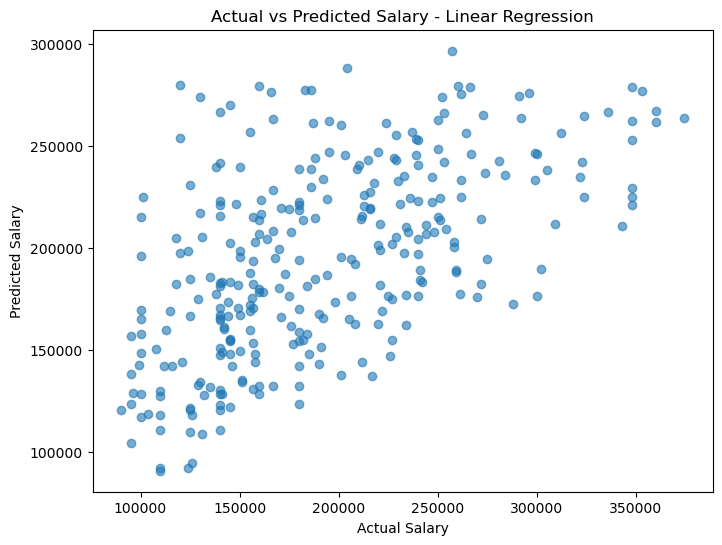

In [23]:
plt.figure(figsize=(8,6))
plt.scatter(y_test_reg, y_pred_lr, alpha=0.6)
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted Salary - Linear Regression")
plt.show()

The scatter plot shows a positive relationship between actual and predicted salaries, meaning the model captures general salary trends. However, the spread of points indicates that some prediction errors still remain.

## Improving Salary Prediction with Gradient Boosting Regressor

After using Linear Regression as a baseline model, I now apply Gradient Boosting Regressor. This model can capture more complex and non-linear relationships in salary data.

In [24]:
from sklearn.ensemble import GradientBoostingRegressor

gbr_model = Pipeline(steps=[
    ("preprocessor", preprocessor_reg),
    ("regressor", GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    ))
])

gbr_model.fit(X_train_reg, y_train_reg)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['demand_score',
                                                   'ai_salary_premium_pct']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['education_required',
                                                   'required_skills',
                                                   'experience_level'])])),
                ('regressor', GradientBoostingRegressor(random_state=42))])

## Predicting Salaries with Gradient Boosting

Now I generate salary predictions for the test dataset.

In [25]:
y_pred_gbr = gbr_model.predict(X_test_reg)

## Evaluating Gradient Boosting Regressor

I evaluate the improved model using the same regression metrics.

In [26]:
mae_gbr = mean_absolute_error(y_test_reg, y_pred_gbr)
rmse_gbr = np.sqrt(mean_squared_error(y_test_reg, y_pred_gbr))
r2_gbr = r2_score(y_test_reg, y_pred_gbr)

print("MAE:", mae_gbr)
print("RMSE:", rmse_gbr)
print("R² Score:", r2_gbr)

MAE: 40089.50740683186
RMSE: 51801.75297206947
R² Score: 0.3453440201250796


## Hyperparameter Tuning for Gradient Boosting Regressor

To improve the regression model, I used GridSearchCV to tune the Gradient Boosting Regressor. GridSearchCV tests different combinations of hyperparameters and selects the best model based on cross-validation performance.

For this regression task, I used negative mean squared error as the scoring metric. The final results are interpreted using MAE, RMSE, and R².

In [27]:
# Hyperparameter tuning for Gradient Boosting Regressor using GridSearchCV

param_grid_reg = {
    "regressor__n_estimators": [50, 100],
    "regressor__learning_rate": [0.05, 0.1],
    "regressor__max_depth": [2, 3]
}

grid_search_reg = GridSearchCV(
    estimator=gbr_model,
    param_grid=param_grid_reg,
    cv=3,
    scoring="neg_mean_squared_error"
)

grid_search_reg.fit(X_train_reg, y_train_reg)

print("Best parameters:", grid_search_reg.best_params_)
print("Best cross-validation MSE:", -grid_search_reg.best_score_)
print("Best cross-validation RMSE:", np.sqrt(-grid_search_reg.best_score_))

Best parameters: {'regressor__learning_rate': 0.1, 'regressor__max_depth': 3, 'regressor__n_estimators': 100}
Best cross-validation MSE: 2456221760.3704104
Best cross-validation RMSE: 49560.28410300339


### GridSearchCV Result for Regression

GridSearchCV selected the following best parameters for the Gradient Boosting Regressor:

- `learning_rate = 0.1`
- `max_depth = 3`
- `n_estimators = 100`

The best cross-validation RMSE was approximately **49,560**. Since the target variable is annual salary in USD, this means that the model’s average prediction error is around 49,560 dollars during cross-validation. This gives a more realistic view of model performance than relying only on one train-test split.

In [28]:
# Evaluate the tuned Gradient Boosting Regressor

best_gbr_model = grid_search_reg.best_estimator_

y_train_pred_tuned_reg = best_gbr_model.predict(X_train_reg)
y_val_pred_tuned_reg = best_gbr_model.predict(X_val_reg)
y_test_pred_tuned_reg = best_gbr_model.predict(X_test_reg)

regression_tuned_results = pd.DataFrame([
    {
        "Dataset": "Training",
        "MAE": mean_absolute_error(y_train_reg, y_train_pred_tuned_reg),
        "RMSE": np.sqrt(mean_squared_error(y_train_reg, y_train_pred_tuned_reg)),
        "R2": r2_score(y_train_reg, y_train_pred_tuned_reg)
    },
    {
        "Dataset": "Validation",
        "MAE": mean_absolute_error(y_val_reg, y_val_pred_tuned_reg),
        "RMSE": np.sqrt(mean_squared_error(y_val_reg, y_val_pred_tuned_reg)),
        "R2": r2_score(y_val_reg, y_val_pred_tuned_reg)
    },
    {
        "Dataset": "Test",
        "MAE": mean_absolute_error(y_test_reg, y_test_pred_tuned_reg),
        "RMSE": np.sqrt(mean_squared_error(y_test_reg, y_test_pred_tuned_reg)),
        "R2": r2_score(y_test_reg, y_test_pred_tuned_reg)
    }
])

regression_tuned_results

,Dataset,MAE,RMSE,R2
0,Training,32947.796104,40599.535262,0.645610
1,Validation,39746.366806,50735.602345,0.361755
2,Test,40089.507407,51801.752972,0.345344


### Tuned Regression Model Interpretation

The tuned Gradient Boosting Regressor performs best on the training set, with an RMSE of about **40,600** and an R² score of **0.646**. On the validation and test sets, the RMSE increases to about **50,736** and **51,802**, while the R² scores decrease to **0.362** and **0.345**.

This shows that the model learns useful patterns from the training data, but its performance is weaker on unseen data. The difference between training and validation/test performance suggests some overfitting. However, the validation and test results are close to each other, which means the model generalizes consistently after tuning.

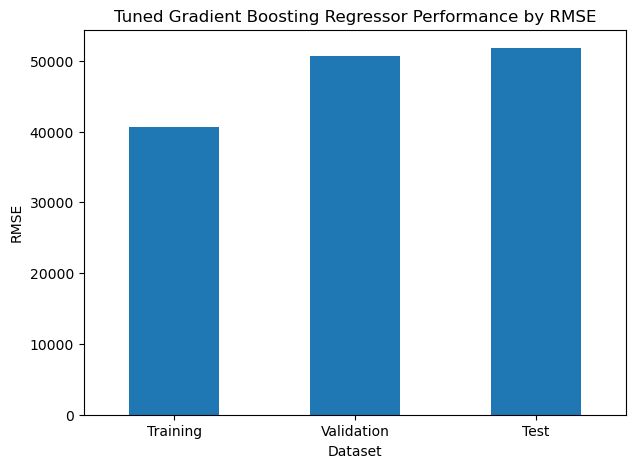

In [29]:
# Visualize tuned regression model performance using RMSE

regression_tuned_results.plot(
    x="Dataset",
    y="RMSE",
    kind="bar",
    legend=False,
    figsize=(7, 5)
)

plt.title("Tuned Gradient Boosting Regressor Performance by RMSE")
plt.ylabel("RMSE")
plt.xticks(rotation=0)
plt.show()

## Visual Comparison of Predictions

The chart below compares actual salaries with predicted salaries from the Gradient Boosting model.

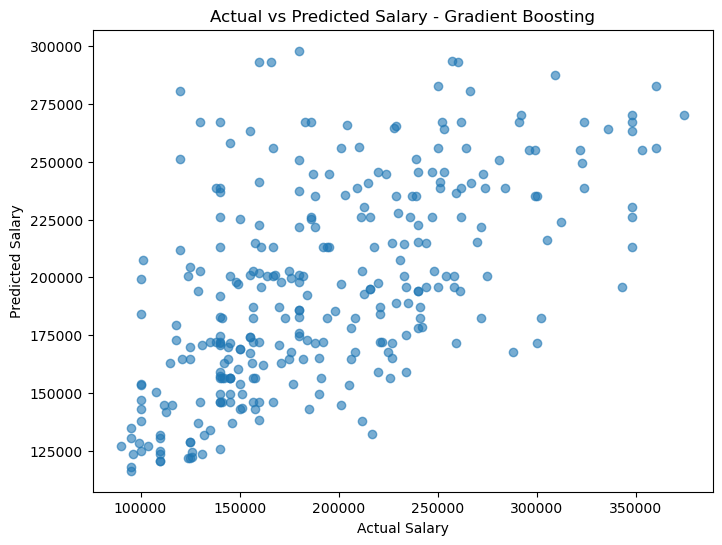

In [30]:
plt.figure(figsize=(8,6))
plt.scatter(y_test_reg, y_pred_gbr, alpha=0.6)
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted Salary - Gradient Boosting")
plt.show()

Even the visuals look almost similar with gradient boosting we have lower MAE and RMSE, and higher R² Score. These illustrates that the model has improved using gradient boosting.

## Comparing Regression Models

To summarize the regression results, I compare Linear Regression and Gradient Boosting using the main evaluation metrics.

In [31]:
regression_results = pd.DataFrame({
    "Model": ["Linear Regression", "Gradient Boosting"],
    "MAE": [mae_lr, mae_gbr],
    "RMSE": [rmse_lr, rmse_gbr],
    "R2 Score": [r2_lr, r2_gbr]
})

regression_results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,42159.163094,53340.848428,0.305865
1,Gradient Boosting,40089.507407,51801.752972,0.345344


The table above shows that Gradient Boosting achieved better overall performance, making it the stronger model for salary prediction in this dataset.

## Final Conclusion

In the classification task, predicting experience level was challenging because job levels may share similar salaries, skills, and education requirements. More advanced models did not significantly improve the results.

In the regression task, salary prediction produced stronger outcomes. Gradient Boosting outperformed Linear Regression, suggesting that salary can be better explained using the available job market variables.

I used both classification and regression models. For classification, I predicted `experience_level` using Logistic Regression and Gradient Boosting. The models were compared using accuracy, precision, recall, and F1-score.

For regression, I predicted `annual_salary_usd` using Linear Regression and Gradient Boosting Regressor. The models were evaluated using MAE, RMSE, and R², which are more appropriate metrics for salary prediction.

GridSearchCV was added to tune the Gradient Boosting models in both classification and regression tasks. The tuned models were evaluated on training, validation, and test sets. These comparisons helped show whether the models generalized well to unseen data.

The regression results showed some signs of overfitting because the training performance was better than the validation and test performance.

Overall, the machine learning phase shows that salary is easier to model than experience level in this dataset.